In [ ]:
import pandas as pd
import numpy as np
import tensorflow as tf
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, LSTM, Input, Dropout
from tensorflow.keras.optimizers import Adam, SGD, RMSprop, Nadam
from tensorflow.keras.callbacks import EarlyStopping
import time
import os
import matplotlib.pyplot as plt
import seaborn as sns
# ==========================================
# 1. WCZYTANIE DANYCH
# ==========================================
filename = 'AirQualityUCI_outcome.xlsx'
df = pd.read_csv(filename)
# Zabezpieczenie typów danych
cols_to_numeric = [c for c in df.columns if c not in ['Date', 'Time', 'Set']]
for col in cols_to_numeric:
    if df[col].dtype == object:
        df[col] = df[col].astype(str).str.replace(',', '.').astype(float)

TARGET_COL = 'C6H6(GT)'
DROP_COLS = ['Date', 'Time', 'Set']
FEATURE_COLS = [c for c in df.columns if c not in DROP_COLS and c != TARGET_COL]

train_df = df[df['Set'] == 'train']
val_df = df[df['Set'] == 'validation']
test_df = df[df['Set'] == 'test']

scaler_X = MinMaxScaler()
scaler_y = MinMaxScaler()

# Fit tylko na train
X_train_raw = scaler_X.fit_transform(train_df[FEATURE_COLS].values)
y_train_raw = scaler_y.fit_transform(train_df[[TARGET_COL]].values)

# Transform na reszcie
X_val_raw = scaler_X.transform(val_df[FEATURE_COLS].values)
y_val_raw = scaler_y.transform(val_df[[TARGET_COL]].values)

X_test_raw = scaler_X.transform(test_df[FEATURE_COLS].values)
y_test_raw_orig = test_df[[TARGET_COL]].values

def create_sequences(X, y, time_steps):
    Xs, ys = [], []
    for i in range(len(X) - time_steps):
        Xs.append(X[i:(i + time_steps)])
        ys.append(y[i + time_steps])
    return np.array(Xs), np.array(ys)


ts = 24  # Ustawienie stałej wartości time_steps, odpowiadającej BASELINE_CONFIG
X_train, y_train_scaled = create_sequences(X_train_raw, y_train_raw, ts)
X_val, y_val_scaled = create_sequences(X_val_raw, y_val_raw, ts)
X_test, y_true_test = create_sequences(X_test_raw, y_test_raw_orig, ts)

# Prawdziwe wartości (do liczenia metryk)
y_true_train = scaler_y.inverse_transform(y_train_scaled)
y_true_val = scaler_y.inverse_transform(y_val_scaled)


In [ ]:
# ==========================================
# 2. BUDOWNICZY MODELU (LSTM)
# ==========================================
def build_lstm_model(input_shape, params):
    model = Sequential()
    model.add(Input(shape=input_shape))

    # Warstwy LSTM
    for i in range(params['num_layers']):
        # return_sequences=True musi być dla wszystkich warstw POZA ostatnią warstwą LSTM
        return_seq = True if i < params['num_layers'] - 1 else False

        model.add(LSTM(units=params['units'],
                       return_sequences=return_seq,
                       activation='tanh'))

        # Dropout
        model.add(Dropout(0.2))

    # Warstwy Dense
    model.add(Dense(params['dense_neurons'], activation='relu'))
    model.add(Dense(1))

    # Optymalizator (SGD usunięte z logiki wyboru, bo dawało błędy)
    lr = params['learning_rate']

    if params['optimizer'] == 'adam': opt = Adam(learning_rate=lr)
    elif params['optimizer'] == 'nadam': opt = Nadam(learning_rate=lr)
    elif params['optimizer'] == 'rmsprop': opt = RMSprop(learning_rate=lr)
    else: opt = Adam(learning_rate=lr)

    model.compile(optimizer=opt, loss='mse')
    return model

# ==========================================
# 3. KONFIGURACJA EKSPERYMENTÓW
# ==========================================

# --- NOWY BASELINE (Najlepsze wyniki z Twojego Grid Search) ---
BASELINE_CONFIG = {
    'group': 'BASELINE',
    'num_layers': 1,           # 1 warstwa wygrała w testach
    'units': 64,               # 64 neurony działały najlepiej
    'dense_neurons': 64,
    'optimizer': 'adam',       # Adam wygrywa z SGD
    'learning_rate': 0.001,
    'momentum': 0.0,           # Niepotrzebne dla Adama
    'epochs': 100,
    'time_steps': 24

}

# --- ZOPTYMALIZOWANE GRUPY TESTOWE ---
TEST_GROUPS = {

    'Layers':       {'param': 'num_layers',    'values': [1, 2, 3, 4]},

    # Skoro 64 było lepsze niż 32, sprawdzamy 128
    'Capacity':     {'param': 'units',         'values': [8,16,32,64]},

    # Sprawdzamy inne dobre optimizery
    'Optimizer':    {'param': 'optimizer',     'values': ['adam', 'nadam', 'rmsprop']},

    # Mniejszy LR dla stabilizacji przy większych sieciach
    'LearningRate': {'param': 'learning_rate', 'values': [0.1, 0.01, 0.001, 0.0001]},

    'Epochs':       {'param': 'epochs',        'values': [25, 50, 100,200]}
}

experiments_queue = []
experiments_queue.append(BASELINE_CONFIG.copy())

for group_name, details in TEST_GROUPS.items():
    param_name = details['param']
    values = details['values']
    for val in values:
        new_cfg = BASELINE_CONFIG.copy()
        new_cfg['group'] = group_name

        if group_name == 'Capacity':
            new_cfg['units'] = val
            new_cfg['dense_neurons'] = val
        else:
            new_cfg[param_name] = val

        # Proste zabezpieczenie przed duplikatami baseline
        if new_cfg[param_name] != BASELINE_CONFIG.get(param_name) or group_name == 'Capacity':
             experiments_queue.append(new_cfg)

# Usuwanie duplikatów
unique_experiments = []
seen_configs = set()
for exp in experiments_queue:
    # Tworzymy klucz unikalności bez nazwy grupy
    config_tuple = tuple(sorted((k, v) for k, v in exp.items() if k != 'group'))
    if config_tuple not in seen_configs:
        seen_configs.add(config_tuple)
        unique_experiments.append(exp)

experiments_queue = unique_experiments

print(f"Zaplanowano {len(experiments_queue)} zoptymalizowanych konfiguracji.")


Zaplanowano 15 zoptymalizowanych konfiguracji.


In [ ]:
# ==========================================
# 4. SILNIK WYKONAWCZY (TRAIN / VAL / TEST)
# ==========================================
N_REPEATS = 5
results = []
current_run = 0
total_runs = len(experiments_queue) * N_REPEATS


ts = BASELINE_CONFIG['time_steps']
X_train, y_train_scaled = create_sequences(X_train_raw, y_train_raw, ts)
X_val, y_val_scaled = create_sequences(X_val_raw, y_val_raw, ts)
X_test, y_true_test = create_sequences(X_test_raw, y_test_raw_orig, ts)

# Prawdziwe wartości (do liczenia metryk)
y_true_train = scaler_y.inverse_transform(y_train_scaled)
y_true_val = scaler_y.inverse_transform(y_val_scaled)

for cfg in experiments_queue:
    # Wyciąganie nazwy testowanego parametru do printa
    tested_param = "BASELINE"
    tested_val = "N/A"
    if cfg['group'] != 'BASELINE':
        # Prosta logika szukania różnic względem baseline
        diff = {k: cfg[k] for k in cfg if k in BASELINE_CONFIG and cfg[k] != BASELINE_CONFIG[k]}
        if diff:
            tested_param = list(diff.keys())[0]
            tested_val = diff[tested_param]
        if cfg['group'] == 'Capacity': tested_param = 'units'; tested_val = cfg['units']

    print(f"\n>>> BADANIE: {cfg['group']} | {tested_param} = {tested_val}")

    metrics = {k: [] for k in ['Train_R2', 'Val_R2', 'Test_R2',
                               'Train_MAE', 'Val_MAE', 'Test_MAE',
                               'Train_MSE', 'Val_MSE', 'Test_MSE']}

    for i in range(N_REPEATS):
        current_run += 1

        # Budowa i Trening
        model = build_lstm_model((X_train.shape[1], X_train.shape[2]), cfg)

        # Callbacki (Epochs group nie ma EarlyStopping, reszta ma)
        cbs = [] if cfg['group'] == 'Epochs' else [EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)]

        model.fit(X_train, y_train_scaled, validation_data=(X_val, y_val_scaled),
                  epochs=cfg['epochs'], batch_size=128, verbose=0, callbacks=cbs)

        # Predykcja (Inverse transform od razu)
        p_train = scaler_y.inverse_transform(model.predict(X_train, verbose=0))
        p_val   = scaler_y.inverse_transform(model.predict(X_val, verbose=0))
        p_test  = scaler_y.inverse_transform(model.predict(X_test, verbose=0))

        # Zabezpieczenie NaN (przypisuje 0 R2 i wysoki błąd jeśli sieć wybuchła)
        if np.isnan(p_test).any():
            print("! UWAGA: NaN w wynikach.")
            scores = [0]*3 + [999]*6 # R2=0, reszta błędów wysoka
        else:
            # Obliczenie i zapisanie wszystkich metryk w jednej krotce
            scores = [
                r2_score(y_true_train, p_train), r2_score(y_true_val, p_val), r2_score(y_true_test, p_test),
                mean_absolute_error(y_true_train, p_train), mean_absolute_error(y_true_val, p_val), mean_absolute_error(y_true_test, p_test),
                mean_squared_error(y_true_train, p_train), mean_squared_error(y_true_val, p_val), mean_squared_error(y_true_test, p_test)
            ]

        # Rozpakowanie wyników do słownika metrics
        for key, val in zip(metrics.keys(), scores):
            metrics[key].append(val)

        print(f"    Run {current_run}/{total_runs}: Test R2={metrics['Test_R2'][-1]:.4f} | MSE={metrics['Test_MSE'][-1]:.2f}")

    # Zapis średnich
    res = cfg.copy()
    for key, val_list in metrics.items():
        res[f'{key}_Mean'] = np.mean(val_list)

    res['Tested_Value'] = tested_val
    results.append(res)



>>> BADANIE: BASELINE | BASELINE = N/A
    Run 1/20: Test R2=0.7764 | MSE=8.18
    Run 2/20: Test R2=0.7842 | MSE=7.90
    Run 3/20: Test R2=0.7948 | MSE=7.51
    Run 4/20: Test R2=0.7813 | MSE=8.00
    Run 5/20: Test R2=0.7861 | MSE=7.83

>>> BADANIE: Capacity | units = 128
    Run 6/20: Test R2=0.7669 | MSE=8.53
    Run 7/20: Test R2=0.7709 | MSE=8.39
    Run 8/20: Test R2=0.7730 | MSE=8.31
    Run 9/20: Test R2=0.7573 | MSE=8.88
    Run 10/20: Test R2=0.7961 | MSE=7.46

>>> BADANIE: Capacity | units = 256
    Run 11/20: Test R2=0.7745 | MSE=8.25
    Run 12/20: Test R2=0.7958 | MSE=7.47
    Run 13/20: Test R2=0.8137 | MSE=6.82
    Run 14/20: Test R2=0.7722 | MSE=8.34
    Run 15/20: Test R2=0.7818 | MSE=7.99

>>> BADANIE: Capacity | units = 512
    Run 16/20: Test R2=0.7675 | MSE=8.51
    Run 17/20: Test R2=0.7704 | MSE=8.40
    Run 18/20: Test R2=0.7757 | MSE=8.21
    Run 19/20: Test R2=0.7956 | MSE=7.48
    Run 20/20: Test R2=0.7789 | MSE=8.09


In [ ]:
# ==========================================
# 5. ZAPIS WYNIKÓW
# ==========================================
df_res = pd.DataFrame(results)
filename_out = 'wyniki_lstm_metrics_full.csv'
df_res.to_csv(filename_out, index=False)

print("\n" + "="*40)
print("             KONIEC TESTÓW (LSTM)       ")
print("="*40)
print(f"Pełne wyniki zapisano w: {filename_out}")

# Krótki podgląd Bazy (dla pewności)
print("\n--- WYNIKI BAZOWE (BASELINE MEAN) ---")
base_res = df_res[df_res['group'] == 'BASELINE']
if not base_res.empty:
    print(f"Train R2: {base_res['Train_R2_Mean'].values[0]:.4f} | MSE: {base_res['Train_MSE_Mean'].values[0]:.4f}")
    print(f"Val   R2: {base_res['Val_R2_Mean'].values[0]:.4f} | MSE: {base_res['Val_MSE_Mean'].values[0]:.4f}")
    print(f"Test  R2: {base_res['Test_R2_Mean'].values[0]:.4f} | MSE: {base_res['Test_MSE_Mean'].values[0]:.4f}")


             KONIEC TESTÓW (LSTM)       
Pełne wyniki zapisano w: wyniki_lstm_metrics_full.csv

--- WYNIKI BAZOWE (BASELINE MEAN) ---
Train R2: 0.8394 | MSE: 9.5549
Val   R2: 0.8469 | MSE: 8.4851
Test  R2: 0.7846 | MSE: 7.8847


In [ ]:
import random

# ==========================================
# 6. RANDOM SEARCH
# ==========================================

N_RANDOM_SAMPLES = 30 # Liczba losowych kombinacji do przetestowania
N_REPEATS = 2

print(f"\n{'='*40}")
print(f"Rozpoczynam RANDOM SEARCH ({N_RANDOM_SAMPLES} prób)\n")

random_experiments_queue = []

# Zaktualizowana przestrzeń poszukiwań dla modelu LSTM
search_space = {
    'num_layers': [ 1,2], # Możliwe liczby warstw LSTM
    'units': [ 32, 64, 128], # Możliwe liczby neuronów w warstwach LSTM
    'dense_neurons': [ 32,64,128], # Możliwe liczby neuronów w warstwie Dense
    'optimizer': ['adam', 'nadam'], # Możliwe optymalizatory
    'learning_rate': [0.01,0.001], # Możliwe stopy uczenia
    'epochs': [25, 50, 100], # Możliwe liczby epok
}


fixed_time_steps = 24 # Z oryginalnego BASELINE_CONFIG
fixed_momentum = 0.0
# --------------------------------------------------------------

for _ in range(N_RANDOM_SAMPLES):
    random_cfg = {
        'group': 'RANDOM_SEARCH',
        'time_steps': fixed_time_steps,
        'momentum': fixed_momentum,
    }

    # Losujemy wartości dla każdego parametru z przestrzeni poszukiwań
    for param, values_list in search_space.items():
        random_cfg[param] = random.choice(values_list)

    random_experiments_queue.append(random_cfg)

print(f"Wygenerowano {len(random_experiments_queue)} losowych konfiguracji do przetestowania.")

random_search_results = []
current_run_rs = 0
total_runs_rs = len(random_experiments_queue) * N_REPEATS

for cfg in random_experiments_queue:
    current_run_rs_exp = 0
    # Zaktualizowany string printujący konfigurację dla LSTM
    print(f"\n>>> RANDOM SEARCH: Konfiguracja {cfg.get('group', 'UNKNOWN')} | " \
          f"Layers: {cfg.get('num_layers', 'N/A')}, Units: {cfg.get('units', 'N/A')}, Dense: {cfg.get('dense_neurons', 'N/A')}, LR: {cfg.get('learning_rate', 'N/A')}")

    metrics = {k: [] for k in ['Train_R2', 'Val_R2', 'Test_R2',
                               'Train_MAE', 'Val_MAE', 'Test_MAE',
                               'Train_MSE', 'Val_MSE', 'Test_MSE']}

    for i in range(N_REPEATS):
        current_run_rs += 1
        current_run_rs_exp += 1


        model = build_lstm_model((X_train.shape[1], X_train.shape[2]), cfg)

        # EarlyStopping tylko jeśli nie testujemy 'Epochs' i jest dostępne w konfiguracji
        cbs = []
        if cfg.get('group') != 'Epochs':
             cbs.append(EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True))

        model.fit(X_train, y_train_scaled, validation_data=(X_val, y_val_scaled),
                  epochs=cfg['epochs'], batch_size=128, verbose=0, callbacks=cbs)

        p_train = scaler_y.inverse_transform(model.predict(X_train, verbose=0))
        p_val   = scaler_y.inverse_transform(model.predict(X_val, verbose=0))
        p_test  = scaler_y.inverse_transform(model.predict(X_test, verbose=0))

        if np.isnan(p_test).any():
            print("! UWAGA: NaN w wynikach. Przypisuję błędy domyślne.")
            scores = [0]*3 + [999]*6
        else:
            scores = [
                r2_score(y_true_train, p_train), r2_score(y_true_val, p_val), r2_score(y_true_test, p_test),
                mean_absolute_error(y_true_train, p_train), mean_absolute_error(y_true_val, p_val), mean_absolute_error(y_true_test, p_test),
                mean_squared_error(y_true_train, p_train), mean_squared_error(y_true_val, p_val), mean_squared_error(y_true_test, p_test)
            ]

        for key, val in zip(metrics.keys(), scores):
            metrics[key].append(val)

        print(f"    Run {current_run_rs}/{total_runs_rs} (Exp {current_run_rs_exp}/{N_REPEATS}): Test R2={metrics['Test_R2'][-1]:.4f} | MSE={metrics['Test_MSE'][-1]:.2f}")

    res = cfg.copy()
    for key, val_list in metrics.items():
        res[f'{key}_Mean'] = np.mean(val_list)

    random_search_results.append(res)

# ==========================================
# ZAPIS WYNIKÓW RANDOM SEARCH I WYBÓR NAJLEPSZEGO MODELU
# ==========================================
df_random_res = pd.DataFrame(random_search_results)
filename_random_out = 'wyniki_lstm_random_search.csv' # Zmieniona nazwa pliku
df_random_res.to_csv(filename_random_out, index=False)

print(f"\n{'='*40}")
print(f"             KONIEC RANDOM SEARCH        ")
print(f"{'='*40}")
print(f"Pełne wyniki random search zapisano w: {filename_random_out}")

# Znajdowanie najlepszego modelu
best_model_rs = df_random_res.loc[df_random_res['Test_R2_Mean'].idxmax()]

print("\n--- NAJLEPSZY MODEL Z RANDOM SEARCH (wg. Test_R2_Mean) ---")
print(f"Konfiguracja:")
# Zaktualizowana lista kluczy do wyświetlenia
for key in ['num_layers', 'units', 'dense_neurons', 'optimizer', 'learning_rate', 'epochs', 'time_steps']:
    if key in best_model_rs:
        print(f"  {key}: {best_model_rs[key]}")

print(f"Wyniki (średnie z {N_REPEATS} powtórzeń):")
print(f"  Train R2: {best_model_rs['Train_R2_Mean']:.4f}")
print(f"  Val   R2: {best_model_rs['Val_R2_Mean']:.4f}")
print(f"  Test  R2: {best_model_rs['Test_R2_Mean']:.4f}")
print(f"  Train MAE: {best_model_rs['Train_MAE_Mean']:.4f}")
print(f"  Val   MAE: {best_model_rs['Val_MAE_Mean']:.4f}")
print(f"  Test  MAE: {best_model_rs['Test_MAE_Mean']:.4f}")
print(f"  Train MSE: {best_model_rs['Train_MSE_Mean']:.4f}")
print(f"  Val   MSE: {best_model_rs['Val_MSE_Mean']:.4f}")
print(f"  Test  MSE: {best_model_rs['Test_MSE_Mean']:.4f}")


Rozpoczynam RANDOM SEARCH (30 prób)

Wygenerowano 30 losowych konfiguracji do przetestowania.

>>> RANDOM SEARCH: Konfiguracja RANDOM_SEARCH | Layers: 1, Units: 32, Dense: 32, LR: 0.001


KeyboardInterrupt: 

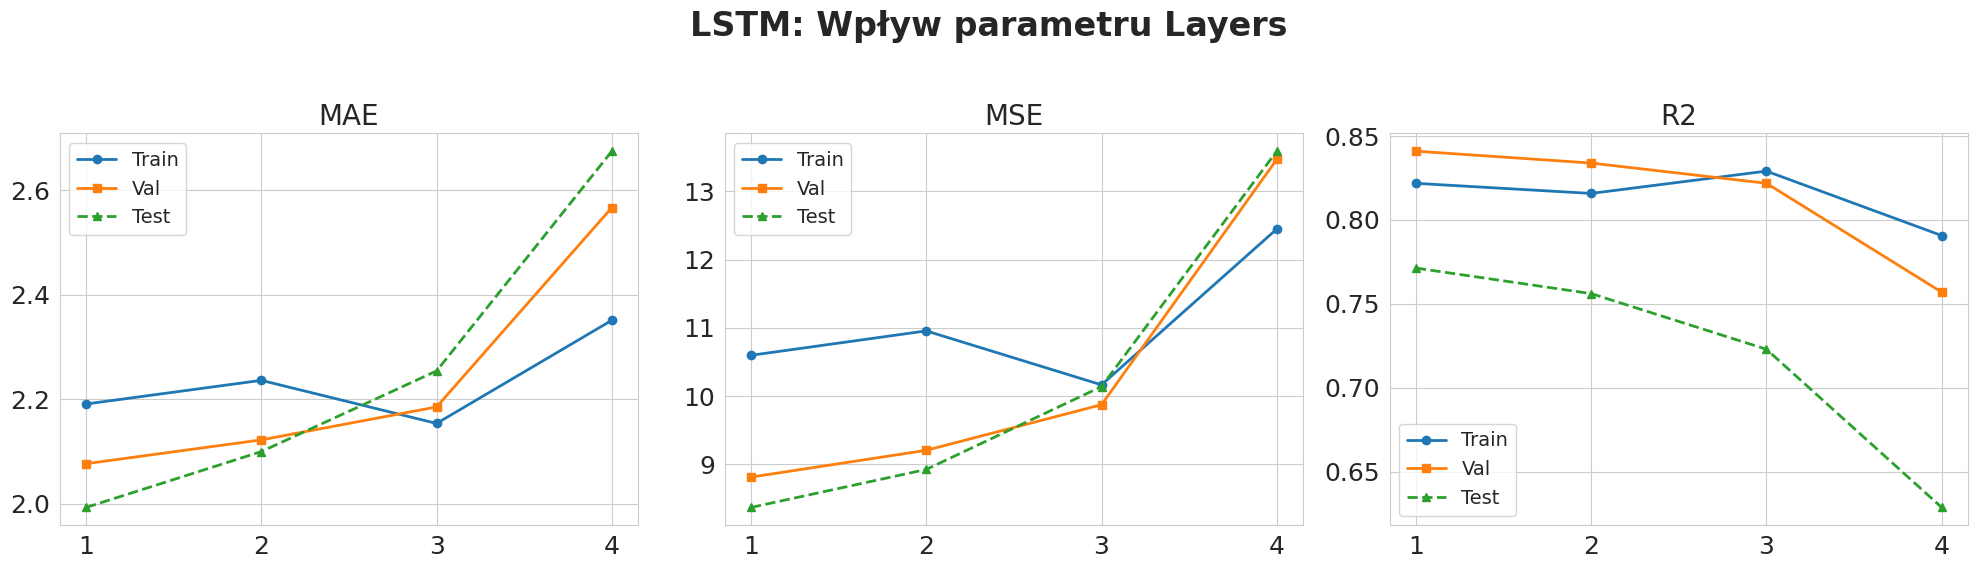

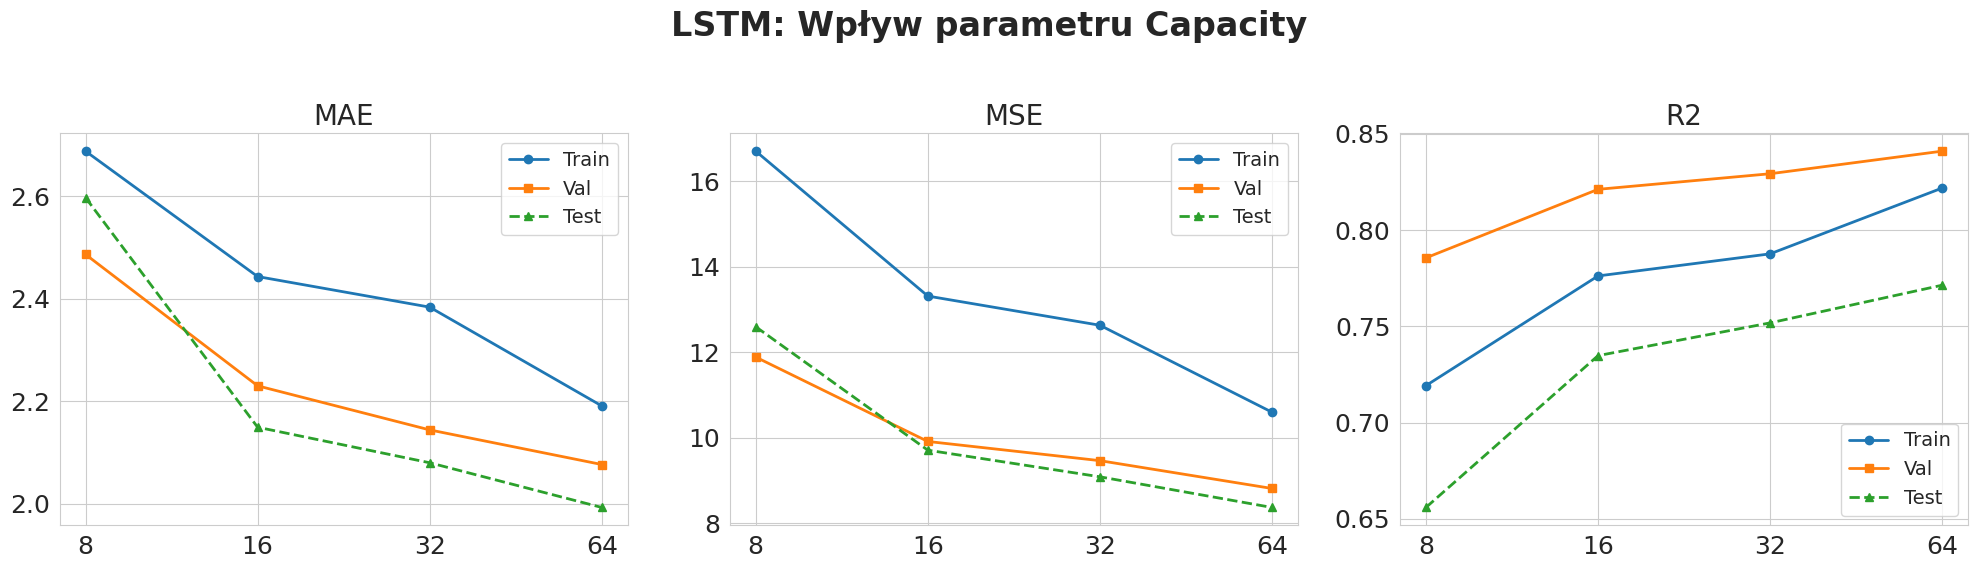

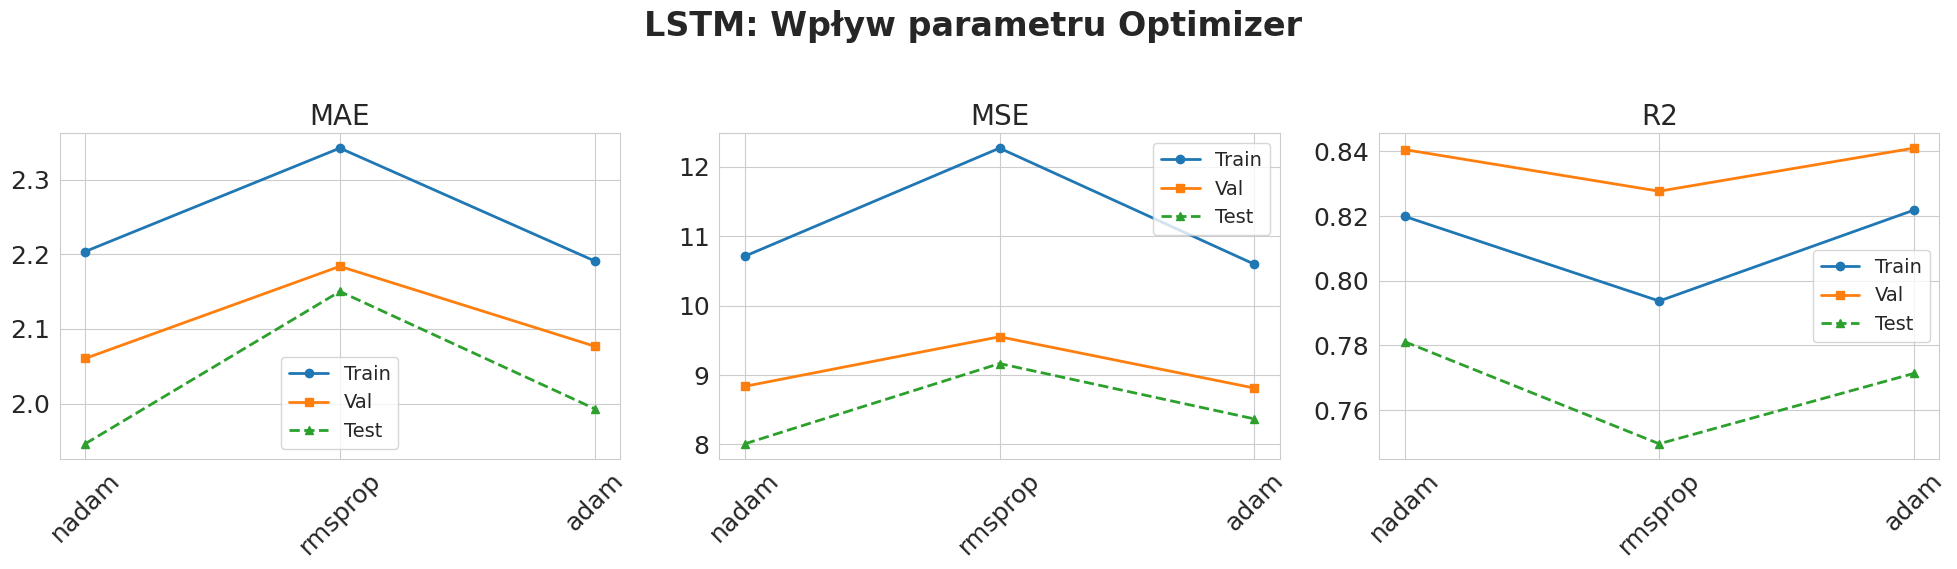

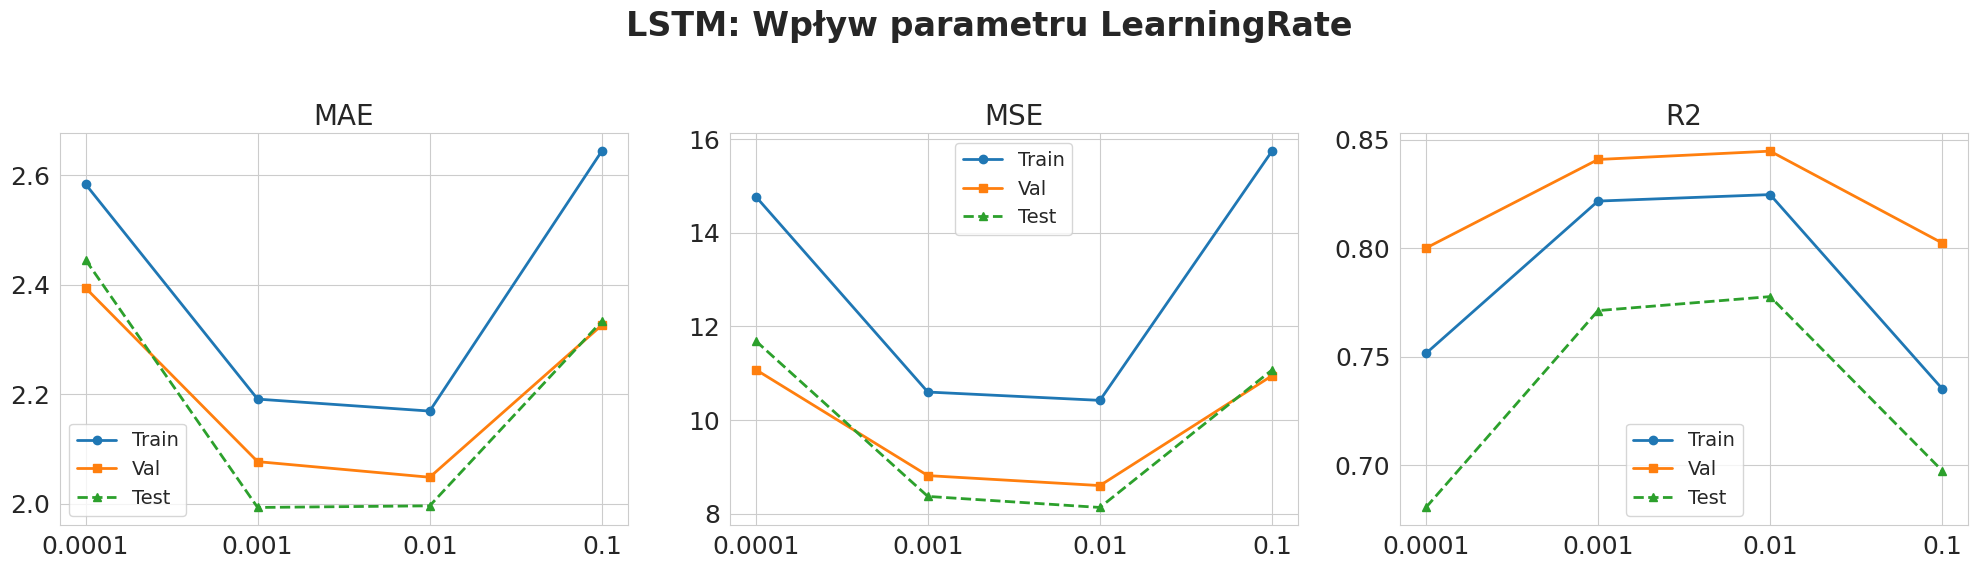

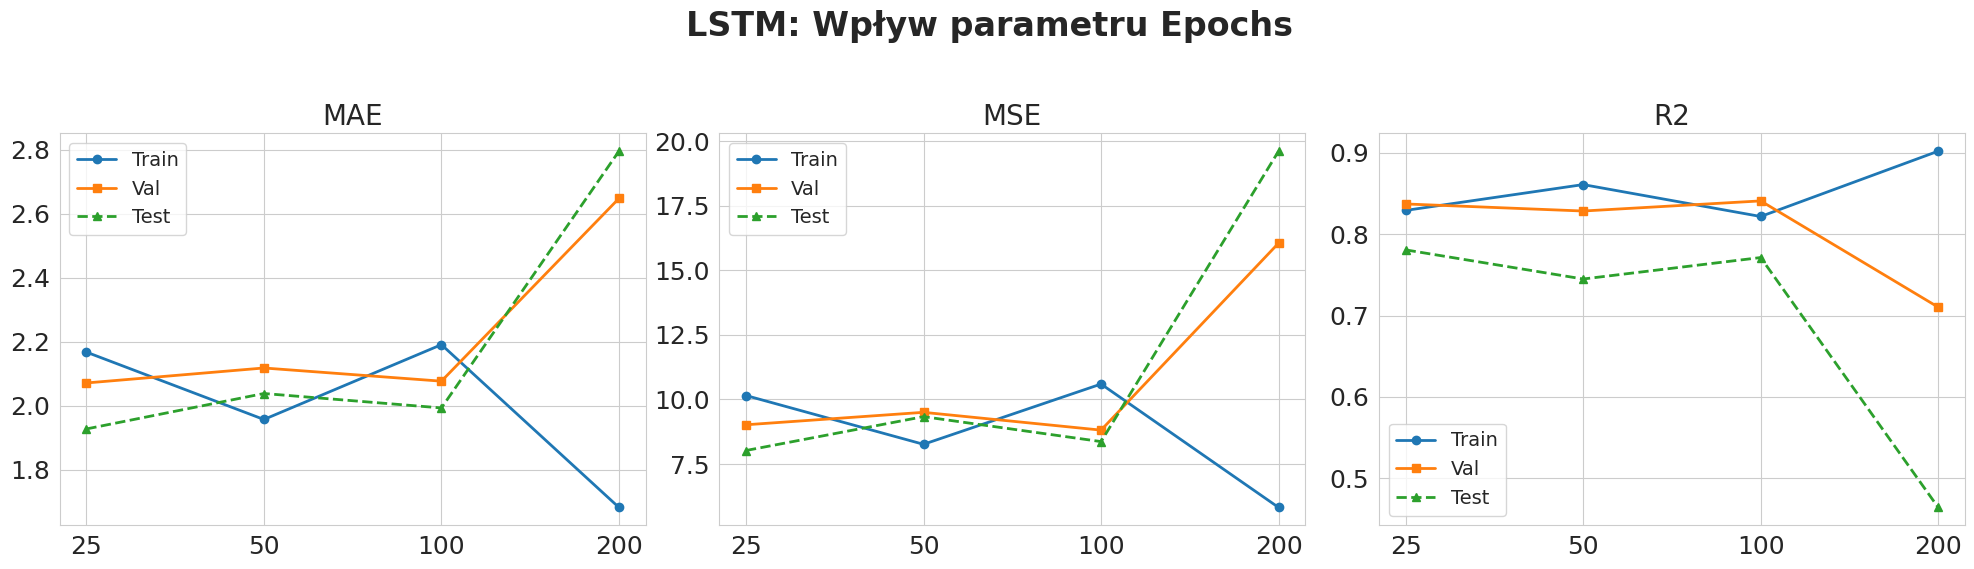

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np

# Wczytanie danych
FILENAME = 'wyniki_lstm_airquality.csv'
df_res = pd.read_csv(FILENAME)

# ==========================================
# KONFIGURACJA STYLU (WEDŁUG SCHEMATU)
# ==========================================
sns.set_style("whitegrid")
plt.rcParams.update({
    'font.size': 14,          # Bazowy rozmiar
    'axes.titlesize': 20,     # Tytuły poszczególnych wykresów
    'xtick.labelsize': 18,    # Liczby na osi X
    'ytick.labelsize': 18,    # Liczby na osi Y
    'legend.fontsize': 14,    # Legenda
    'figure.titlesize': 24    # Tytuł główny
})

param_map = {
    'Layers': 'num_layers',
    'Capacity': 'units',
    'LearningRate': 'learning_rate',
    'Optimizer': 'optimizer',
    'Epochs': 'epochs'
}

baseline_row = df_res[df_res['group'] == 'BASELINE']
test_groups = [g for g in df_res['group'].unique() if g != 'BASELINE']

for group in test_groups:
    if group not in param_map: continue

    x_col = param_map[group]
    subset = df_res[df_res['group'] == group].copy()

    # Dodanie baseline jeśli istnieje
    if not baseline_row.empty:
        subset = pd.concat([subset, baseline_row], ignore_index=True)

    # ---------------------------------------------------------
    # SORTOWANIE (aby wykres szedł od najmniejszej do największej wartości)
    # ---------------------------------------------------------
    try:
        # Próbujemy sortować numerycznie (ważne dla Learning Rate, Epochs itp.)
        subset['sort_val'] = pd.to_numeric(subset[x_col], errors='coerce')
        subset = subset.sort_values('sort_val')
    except:
        # Fallback dla stringów (np. Optimizer)
        subset = subset.sort_values(x_col)

    # ---------------------------------------------------------
    # KLUCZ DO RÓWNYCH ODSTĘPÓW
    # ---------------------------------------------------------
    # Tworzymy listę pozycji  dla każdego punktu
    x_positions = np.arange(len(subset))
    # Etykiety to rzeczywiste wartości z kolumny parametru
    x_labels = subset[x_col].astype(str).values

    fig, axes = plt.subplots(1, 3, figsize=(20, 6))
    fig.suptitle(f'LSTM: Wpływ parametru {group}', fontsize=24, fontweight='bold')

    # Konfiguracja metryk (Nazwa wykresu, kolumna Train, kolumna Val, kolumna Test)
    # Dostosowałem nazwy kolumn do Twojego DataFrame (z sufiksami _Mean)
    metrics_config = [
        ('MAE', 'Train_MAE_Mean', 'Val_MAE_Mean', 'Test_MAE_Mean'),
        ('MSE', 'Train_MSE_Mean', 'Val_MSE_Mean', 'Test_MSE_Mean'),
        ('R2', 'Train_R2_Mean', 'Val_R2_Mean', 'Test_R2_Mean')
    ]

    for i, (name, tr_col, val_col, test_col) in enumerate(metrics_config):
        ax = axes[i]

        # Rysujemy względem pozycji (0, 1, 2...), a nie wartości
        # Styl linii wzięty ze schematu: Train(o), Val(s), Test(^, --)
        ax.plot(x_positions, subset[tr_col], marker='o', label='Train', linewidth=2)
        ax.plot(x_positions, subset[val_col], marker='s', label='Val', linewidth=2)
        ax.plot(x_positions, subset[test_col], marker='^', label='Test', linewidth=2, linestyle='--')

        ax.set_title(name)

        # Ustawiamy etykiety w równych odstępach
        ax.set_xticks(x_positions)
        ax.set_xticklabels(x_labels)

        # Rotacja dla Optimizera, żeby napisy na siebie nie wchodziły
        if group == 'Optimizer':
            ax.tick_params(axis='x', rotation=45)

        ax.legend()
        ax.grid(True) # Opcjonalnie, whitegrid i tak to robi, ale dla pewności

    plt.tight_layout(rect=[0, 0.03, 1, 0.95])
    plt.show()